<a href="https://colab.research.google.com/github/Nirupama-Halder/Google-Colab-practice-notebooks/blob/main/practice_problem_module_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.DataFrame({
    'Age': [18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70]
})

In [ ]:
mean_of_age = df['Age'].mean()
print(mean_of_age)
std_of_age = df['Age'].std()
print(std_of_age)

28.4
12.132600710482482


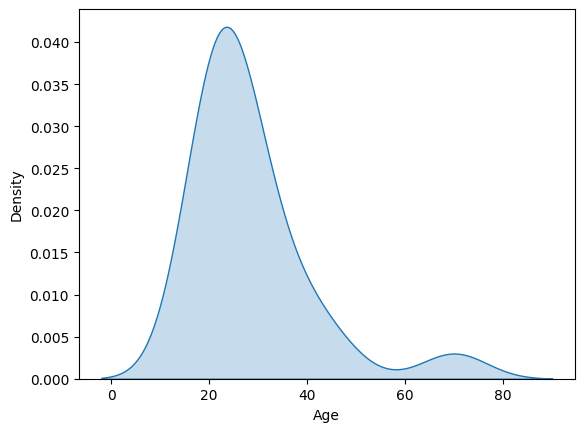

In [ ]:
sns.kdeplot(data=df,x='Age',fill=True)
plt.show()

In [ ]:
X = df[['Age']]
X_train,X_test = train_test_split(X,test_size = 0.2,random_state = 42)
X_train


,Age
8,23
5,21
11,26
3,20
18,45
16,35
13,28
2,20
9,24
19,70


In [ ]:
X_train['zscore_age'] = (X_train['Age']-mean_of_age)/std_of_age
X_train

,Age,zscore_age
8,23,-0.445082
5,21,-0.609927
11,26,-0.197814
3,20,-0.692349
18,45,1.368214
16,35,0.543989
13,28,-0.032969
2,20,-0.692349
9,24,-0.362659
19,70,3.428778


In [ ]:
outliers = X_train[abs(X_train['zscore_age'])>3]
print(len(outliers))
display(outliers)


1


,Age,zscore_age
19,70,3.428778


In [ ]:
new_df = X_train[abs(X_train['zscore_age'])<=3]
print(len(new_df))
new_df


15


,Age,zscore_age
8,23,-0.445082
5,21,-0.609927
11,26,-0.197814
3,20,-0.692349
18,45,1.368214
16,35,0.543989
13,28,-0.032969
2,20,-0.692349
9,24,-0.362659
4,21,-0.609927


In [ ]:
df = pd.DataFrame({
    'salaries' : [25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]
})
X = df[['salaries']]
X_train,X_test = train_test_split(X,test_size = 0.2, random_state = 42)
#X_train
#X_test
#sns.boxplot(data=df,x = 'salaries')
#plt.show()
salaries_Q1 = X_train['salaries'].quantile(0.25)
salaries_Q3 = X_train['salaries'].quantile(0.75)
salaries_IQR = salaries_Q3 - salaries_Q1
print(f'salaries_IQR:{salaries_IQR}')
lower_bound = salaries_Q1 - 1.5*salaries_IQR
upper_bound = salaries_Q3 + 1.5*salaries_IQR
print(f'lower_bound:{lower_bound}')
print(f'upper_bound:{upper_bound}')
salaries_outliers = X_train[(X_train['salaries']<lower_bound)|(X_train['salaries']>upper_bound)]
print(f'len of salaries_outliers:{len(salaries_outliers)}')
display(salaries_outliers)

salaries_outliers = X_test[(X_test['salaries']<lower_bound)|(X_test['salaries']>upper_bound)]
print(f'len of salaries_outliers:{len(salaries_outliers)}')
display(salaries_outliers)



salaries_IQR:38.0
lower_bound:-22.5
upper_bound:129.5
len of salaries_outliers:3


,salaries
22,200
21,150
24,500


len of salaries_outliers:1


,salaries
23,250


In [ ]:
X_train_capped = X_train.copy()
X_train_capped['salaries'] = X_train_capped['salaries'].clip(lower_bound,upper_bound)
display(X_train_capped)

min = X_train_capped['salaries'].min()
max = X_train_capped['salaries'].max()
print(f'min:{min}')
print(f'max:{max}')


,salaries
9,38.0
13,48.0
1,28.0
22,129.5
5,33.0
2,30.0
12,45.0
15,55.0
3,32.0
4,32.0


min:28.0
max:129.5


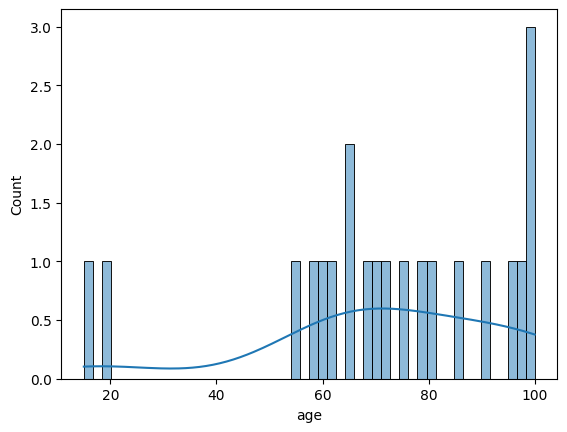

In [ ]:
age = [55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]
df = pd.DataFrame({
    'age': age
})
sns.histplot(data = df, x ='age',bins = 50,kde = True)
plt.show()


Dataset A is left-skewed because a few very small values (15 and 20) create a tail on the left side.

I would choose the IQR method because it works better for skewed datasets and is more robust to outliers than the Z-Score method.

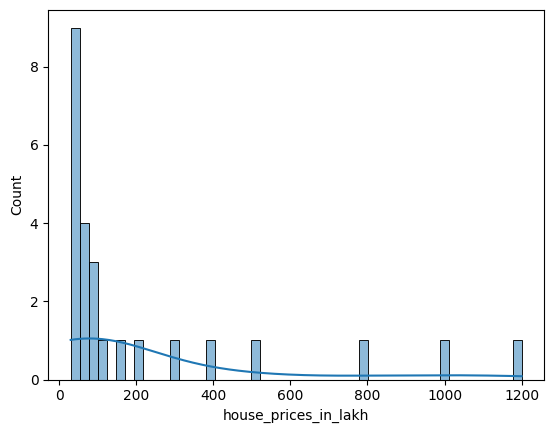

In [ ]:
house_prices_in_lakh = [30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200]
df = pd.DataFrame({
    'house_prices_in_lakh': house_prices_in_lakh
})
sns.histplot(data = df, x ='house_prices_in_lakh',bins = 50,kde = True)
plt.show()



Dataset B is right-skewed because a few very large values create a tail on the right side.

I would choose the IQR method because it works better for skewed datasets and is more robust to outliers than the ZScore method.